# 03 — Auditoria das tabelas e benchmark local

Fontes exatas: [Yang et al., arXiv:2204.08610v2](https://arxiv.org/abs/2204.08610v2), Tabelas 2–4, páginas 4–5; [Buslaev et al., arXiv:1809.06839v1](https://arxiv.org/abs/1809.06839v1), Tabela I, página 3. Os PDFs estão em `../articles/`.

A primeira parte **transcreve e verifica aritmética**, não reexecuta as redes dos artigos. A segunda mede transformações reais no ambiente atual, com protocolo explícito. Valores históricos e tempos locais são apresentados em figuras separadas.

In [1]:
from pathlib import Path
import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'seminar_3/articles').is_dir())
SEMINAR = ROOT / 'seminar_3'
OUT = SEMINAR / 'data/outputs'
PROCESSED = SEMINAR / 'data/processed'
OUT.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def save_csv(path, rows):
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

Tabela 2 / VOC / DeepLabV3+: declarado=0.53; diferença=0.43 p.p.
Tabela 3 / CIFAR-10 / Shake-ResNet: declarado=1.11; diferença=1.14 p.p.
Tabela 3 / SVHN / Wide-ResNet: declarado=0.80; diferença=0.08 p.p.
Tabela 3 / SVHN / Shake-ResNet: declarado=0.30; diferença=0.03 p.p.
Tabela 4 / COCO2017 / Faster R-CNN mAP: declarado=2.40; diferença=0.40 p.p.


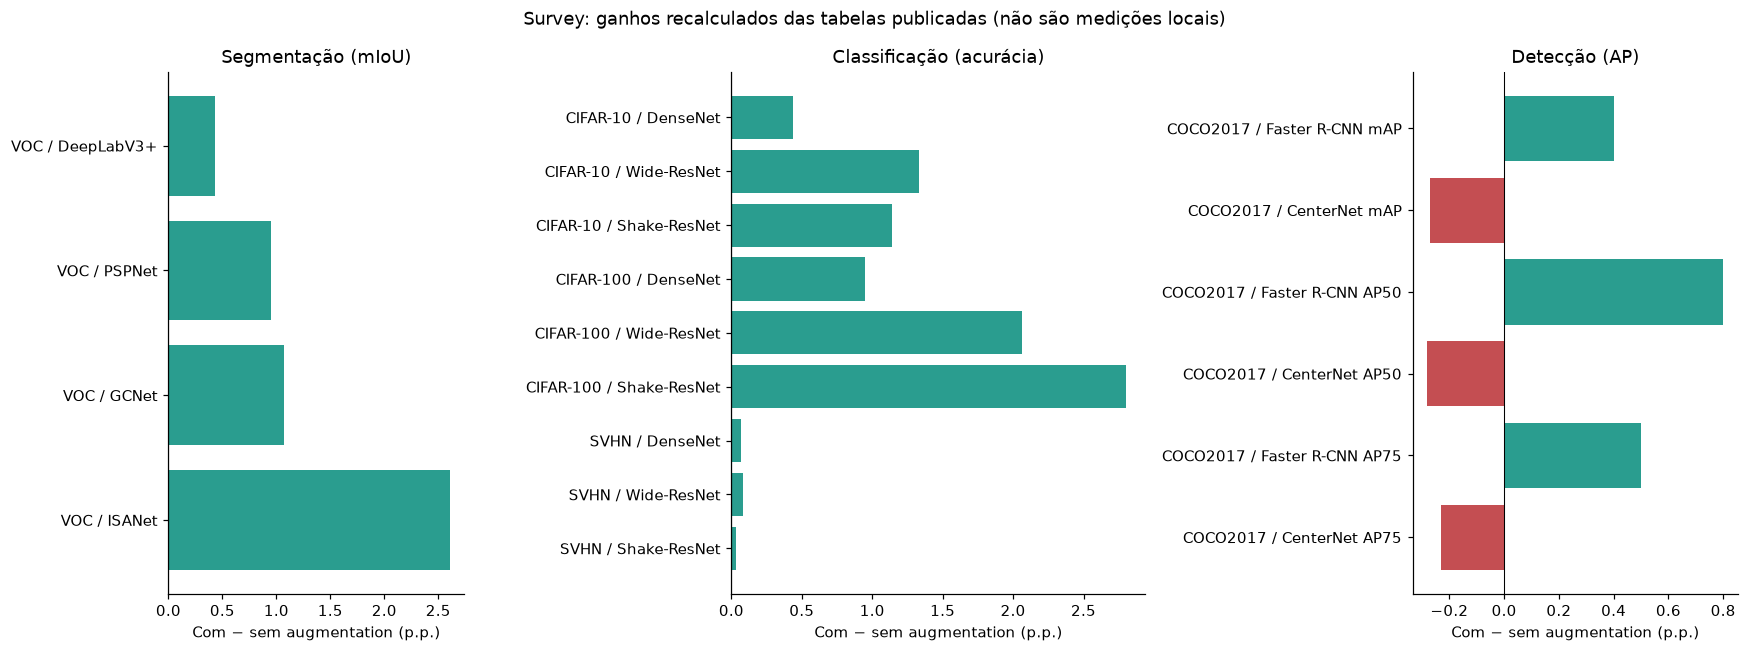

In [2]:
# Colunas: tabela, dataset, modelo/métrica, sem, com, ganho declarado no PDF.
data = [
    (2, 'VOC', 'DeepLabV3+', 75.32, 75.75, 0.53),
    (2, 'VOC', 'PSPNet', 73.38, 74.33, 0.95),
    (2, 'VOC', 'GCNet', 71.86, 72.93, 1.07),
    (2, 'VOC', 'ISANet', 71.65, 74.26, 2.61),
    (3, 'CIFAR-10', 'DenseNet', 94.15, 94.59, 0.44),
    (3, 'CIFAR-10', 'Wide-ResNet', 93.34, 94.67, 1.33),
    (3, 'CIFAR-10', 'Shake-ResNet', 93.70, 94.84, 1.11),
    (3, 'CIFAR-100', 'DenseNet', 74.98, 75.93, 0.95),
    (3, 'CIFAR-100', 'Wide-ResNet', 74.46, 76.52, 2.06),
    (3, 'CIFAR-100', 'Shake-ResNet', 73.96, 76.76, 2.80),
    (3, 'SVHN', 'DenseNet', 97.91, 97.98, 0.07),
    (3, 'SVHN', 'Wide-ResNet', 98.23, 98.31, 0.80),
    (3, 'SVHN', 'Shake-ResNet', 98.37, 98.40, 0.30),
    (4, 'COCO2017', 'Faster R-CNN mAP', 36.40, 36.80, 2.40),
    (4, 'COCO2017', 'CenterNet mAP', 41.42, 41.15, -0.27),
    (4, 'COCO2017', 'Faster R-CNN AP50', 57.20, 58.00, 0.80),
    (4, 'COCO2017', 'CenterNet AP50', 58.29, 58.01, -0.28),
    (4, 'COCO2017', 'Faster R-CNN AP75', 39.50, 40.00, 0.50),
    (4, 'COCO2017', 'CenterNet AP75', 45.53, 45.30, -0.23),
]
rows = [dict(table=t, dataset=d, model=m, without=w, with_aug=a, reported_gain=g,
             calculated_pp=round(a-w, 2), inconsistent=not np.isclose(a-w,g,atol=0.011))
        for t,d,m,w,a,g in data]
save_csv(PROCESSED / 'survey_tables_2_3_4.csv', rows)
for r in rows:
    if r['inconsistent']:
        print(f"Tabela {r['table']} / {r['dataset']} / {r['model']}: declarado={r['reported_gain']:.2f}; diferença={r['calculated_pp']:.2f} p.p.")
assert sum(r['inconsistent'] for r in rows) == 5
assert np.isclose(rows[0]['calculated_pp'], 0.43)
assert np.isclose(rows[13]['calculated_pp'], 0.40)
fig, axes = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={'width_ratios':[1, 1.4, 1.1]})
for ax, table, title in zip(axes, [2,3,4], ['Segmentação (mIoU)', 'Classificação (acurácia)', 'Detecção (AP)'], strict=True):
    selected = [r for r in rows if r['table']==table]
    labels = [r['dataset']+' / '+r['model'] for r in selected]
    values = [r['calculated_pp'] for r in selected]
    ax.barh(labels, values, color=['#2a9d8f' if v>=0 else '#c44e52' for v in values])
    ax.axvline(0, color='black', lw=0.7)
    ax.set(title=title, xlabel='Com − sem augmentation (p.p.)')
    ax.invert_yaxis()
fig.suptitle('Survey: ganhos recalculados das tabelas publicadas (não são medições locais)')
fig.tight_layout(); fig.savefig(OUT / 'survey_gains.png', bbox_inches='tight'); plt.show()

### O que a tabela efetivamente sustenta
Há cinco divergências em relação à subtração dos valores publicados; preservamos ambos os campos, sem supor qual número foi digitado errado. A tolerância de 0,011 p.p. considera o arredondamento da tabela. Os ganhos recalculados **não corrigem as medições originais**.

As linhas do CenterNet apresentam piora nas três métricas. Logo, estas tabelas não sustentam uma promessa de melhoria universal. As linhas combinam políticas e não permitem atribuir o ganho a Mixup, Cutout ou uma transformação isolada.

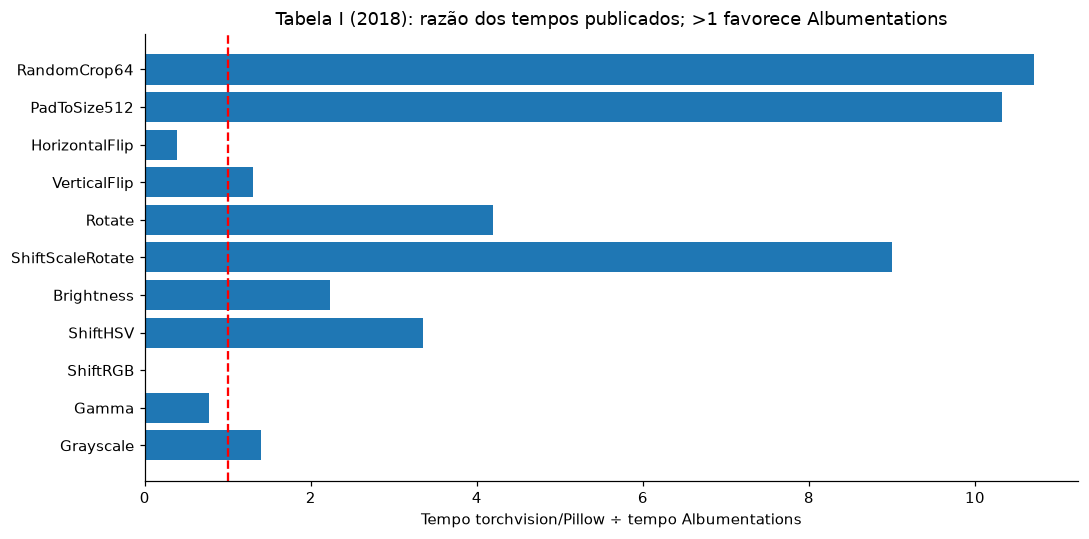

Albumentations tem o menor tempo em 8 de 11 operações entre as alternativas disponíveis.


In [3]:
# Tabela I inteira, ordem: Albumentations, imgaug, torchvision/Pillow, Pillow-SIMD, Keras.
nan = float('nan')
historical = {
    'RandomCrop64': [0.0017,nan,0.0182,0.0182,nan],
    'PadToSize512': [0.2413,nan,2.493,2.3682,nan],
    'HorizontalFlip': [0.7765,2.2299,0.3031,0.3054,2.0508],
    'VerticalFlip': [0.178,0.3899,0.2326,0.2308,0.1799],
    'Rotate': [3.8538,4.0581,16.16,9.5011,50.8632],
    'ShiftScaleRotate': [2.0605,2.4478,18.5401,10.6062,47.0568],
    'Brightness': [2.1018,2.3607,4.6854,3.4814,9.9237],
    'ShiftHSV': [10.3925,14.2255,34.7778,27.0215,nan],
    'ShiftRGB': [2.6159,2.1989,nan,nan,3.0598],
    'Gamma': [1.4832,nan,1.1397,1.1447,nan],
    'Grayscale': [1.2048,5.3895,1.6826,1.2721,nan],
}
libraries = ['Albumentations','imgaug','torchvision Pillow','torchvision Pillow-SIMD','Keras']
save_csv(PROCESSED / 'albumentations_table_1.csv',
         [dict(operation=op, **dict(zip(libraries, values, strict=True))) for op,values in historical.items()])
ratio = np.array([v[2]/v[0] for v in historical.values()])
assert sum(np.nanargmin(v)==0 for v in historical.values()) == 8
assert ratio[2] < 1 and ratio[4] > 4
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(historical), ratio); ax.axvline(1,color='red',ls='--')
ax.set(xlabel='Tempo torchvision/Pillow ÷ tempo Albumentations', title='Tabela I (2018): razão dos tempos publicados; >1 favorece Albumentations')
ax.invert_yaxis(); fig.tight_layout(); fig.savefig(OUT / 'paper_speedup.png', bbox_inches='tight'); plt.show()
print('Albumentations tem o menor tempo em 8 de 11 operações entre as alternativas disponíveis.')

## Benchmark local: mesmo conteúdo, saída materializada
O PDF chama os tempos de “segundos por tarefa de transformação”, mas não fornece detalhes suficientes para equiparar esses valores a latências modernas por imagem. Não os convertemos para FPS.

Abaixo comparamos Albumentations 2.0.8 e torchvision funcional com backend Pillow, CPU, RGB uint8 256×256, uma thread OpenCV, 20 aquecimentos, 5 repetições de 100 imagens. A entrada e a saída são arrays NumPy contíguos nos dois caminhos; as conversões Pillow entram no tempo. Isso mede o custo de um pipeline com esse contrato, não apenas o núcleo de cada biblioteca. A ordem dos métodos é sorteada por repetição. São operações determinísticas equivalentes: flip horizontal, vertical e brilho ×1,2, sem clipping ambíguo.

Não é réplica do benchmark de 2018 e não deve ser usada para um ranking universal.

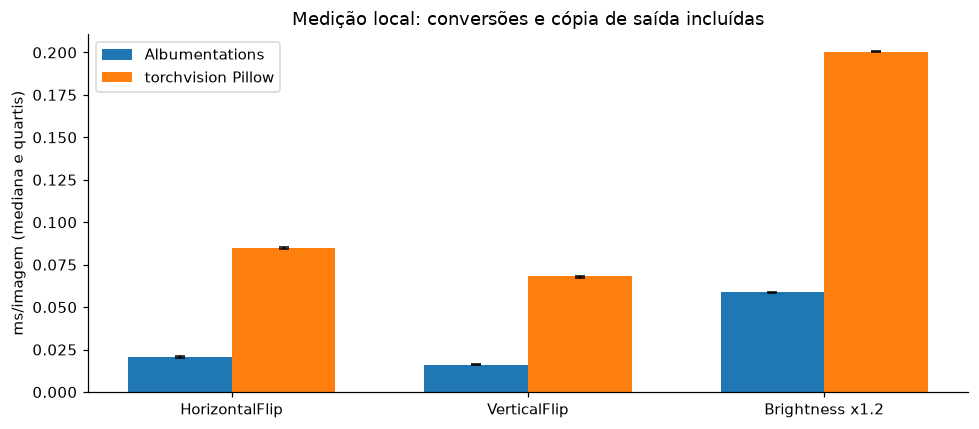

{'operation': 'HorizontalFlip', 'library': 'Albumentations', 'median_ms': 0.020772759999999998, 'q1_ms': 0.02005775, 'q3_ms': 0.02127395}
{'operation': 'HorizontalFlip', 'library': 'torchvision Pillow', 'median_ms': 0.08489492, 'q1_ms': 0.08421374000000001, 'q3_ms': 0.08514763}
{'operation': 'VerticalFlip', 'library': 'Albumentations', 'median_ms': 0.016044489999999998, 'q1_ms': 0.01595958, 'q3_ms': 0.01657177}
{'operation': 'VerticalFlip', 'library': 'torchvision Pillow', 'median_ms': 0.06823407000000001, 'q1_ms': 0.06732222, 'q3_ms': 0.06828477000000001}
{'operation': 'Brightness x1.2', 'library': 'Albumentations', 'median_ms': 0.05875872, 'q1_ms': 0.05843425, 'q3_ms': 0.058851230000000004}
{'operation': 'Brightness x1.2', 'library': 'torchvision Pillow', 'median_ms': 0.20053999, 'q1_ms': 0.20028415, 'q3_ms': 0.2007196}


In [4]:
import time
import platform
import importlib.metadata
import albumentations as A
import cv2
from torchvision.transforms import functional as TF
cv2.setNumThreads(1)
rng = np.random.default_rng(558)
images = rng.integers(0, 180, (100,256,256,3), dtype=np.uint8)
operations = {
    'HorizontalFlip': (A.HorizontalFlip(p=1), TF.hflip),
    'VerticalFlip': (A.VerticalFlip(p=1), TF.vflip),
    'Brightness x1.2': (A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.2,0.2), p=1),
                       lambda im: TF.adjust_brightness(im,1.2)),
}
measurements = []
for name, (alb, pillow) in operations.items():
    funcs = {
        'Albumentations': lambda im: np.array(alb(image=im)['image'], copy=True, order='C'),
        'torchvision Pillow': lambda im: np.array(pillow(Image.fromarray(im)), copy=True, order='C'),
    }
    a,b = [fn(images[0]) for fn in funcs.values()]
    assert a.shape == b.shape == images[0].shape and a.dtype == b.dtype == np.uint8
    assert np.max(np.abs(a.astype(int)-b.astype(int))) <= 1
    for fn in funcs.values():
        for im in images[:20]: fn(im)
    for repeat in range(5):
        for library in rng.permutation(list(funcs)):
            started = time.perf_counter_ns()
            for im in images: output = funcs[library](im)
            elapsed = time.perf_counter_ns() - started
            measurements.append(dict(operation=name, library=library, repeat=repeat,
                                     ms_per_image=elapsed / len(images) / 1e6))
save_csv(OUT / 'benchmark_raw.csv', measurements)
benchmark = []
for name in operations:
    for library in funcs:
        values = [r['ms_per_image'] for r in measurements if r['operation']==name and r['library']==library]
        q1,median,q3 = np.percentile(values,[25,50,75])
        benchmark.append(dict(operation=name, library=library, median_ms=float(median), q1_ms=float(q1), q3_ms=float(q3)))
save_csv(OUT / 'benchmark_summary.csv', benchmark)
metadata = dict(python=platform.python_version(), platform=platform.platform(), cpu=platform.processor(),
                versions={p:importlib.metadata.version(p) for p in ['albumentations','torchvision','Pillow','numpy','opencv-python-headless']},
                shape=[256,256,3], dtype='uint8', image_count=100, repeats=5, warmup=20,
                cv_threads=1, seed=558, contract='numpy RGB -> numpy RGB contiguous; includes conversions and output copy')
(OUT / 'benchmark_protocol.json').write_text(json.dumps(metadata,indent=2))
fig, ax = plt.subplots(figsize=(9,4))
for offset,library in enumerate(funcs):
    selected=[r for r in benchmark if r['library']==library]
    median=np.array([r['median_ms'] for r in selected])
    errors=np.array([[r['median_ms']-r['q1_ms'] for r in selected],[r['q3_ms']-r['median_ms'] for r in selected]])
    ax.bar(np.arange(3)+(offset-0.5)*0.35,median,width=0.35,yerr=errors,capsize=3,label=library)
ax.set_xticks(np.arange(3),list(operations)); ax.set(ylabel='ms/imagem (mediana e quartis)', title='Medição local: conversões e cópia de saída incluídas')
ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'benchmark_local.png',bbox_inches='tight'); plt.show()
for row in benchmark: print(row)
assert all(r['median_ms'] > 0 for r in benchmark)

## Conclusão para a apresentação
As tabelas permitem discutir ganhos e exceções; os testes geométricos do notebook 01 verificam consistência de rótulos; o notebook 02 mede generalização; este benchmark mede custo computacional. São evidências diferentes e complementares.

As versões exatas e condições locais ficam em JSON; todas as medições e transcrições ficam em CSV. O método mais rápido depende da operação e do formato de entrada/saída. A imagem sintética não representa toda a diversidade de imagens reais.